# 👥 Notebook 2: User-Based Collaborative Filtering

## ¿De Qué Va Este Algoritmo?

**Idea Básica**: 
"Si dos usuarios han puesto calificaciones SIMILARES a los MISMOS productos, probablemente tengan gustos parecidos."

**Ejemplo Real**:
- Tú eres el Usuario A, y pusiste 5⭐ a un vestido X y 4⭐ a unos zapatos Y
- El Usuario B puso 5⭐ al vestido X y 4⭐ a los zapatos Y (¡igual que tú!)
- El Usuario B también puso 5⭐ a una chaqueta Z (que tú no has visto)
- **Conclusión**: ¡Probablemente tú también te guste la chaqueta Z!

## Pasos del Algoritmo
1. **Matriz de Ratings**: Crear tabla usuario × producto con calificaciones
2. **Similitud de Usuarios**: Calcular qué tan parecido es cada usuario con los demás
3. **Encontrar Vecinos**: Buscar los K usuarios más similares a nosotros
4. **Predecir Ratings**: Usar los ratings de esos usuarios parecidos para predecir
5. **Recomendar**: Sugerir los productos con calificaciones predichas más altas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Rutas - funciona en Jupyter y scripts
current_dir = Path().cwd()
if 'notebooks' in str(current_dir):
    BASE_DIR = current_dir.parent
else:
    BASE_DIR = current_dir

DATA_FILE = BASE_DIR / 'data' / 'raw' / 'fashion_reviews.json'

# Si no existe, buscar
if not DATA_FILE.exists():
    possible_paths = list(BASE_DIR.glob('**/fashion_reviews.json'))
    if possible_paths:
        DATA_FILE = possible_paths[0]

print(f"📂 Directorio base: {BASE_DIR}")
print(f"📄 Datos: {DATA_FILE.exists() and '✅ Encontrado' or '❌ No encontrado'}")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Rutas
BASE_DIR = Path().cwd()  # Cambiar si es necesario
if 'notebooks' in str(BASE_DIR):
    BASE_DIR = BASE_DIR.parent  # Subir un nivel si estamos en notebooks/

DATA_FILE = BASE_DIR / 'data' / 'raw' / 'fashion_reviews.json'

print(f"📂 Directorio base: {BASE_DIR}")
print(f"📄 Datos en: {DATA_FILE}")
print(f"   ¿Existe? {DATA_FILE.exists()}")

📂 Directorio base: d:\work\repos-deep-learning\recommendation-fashion
📄 Datos en: d:\work\repos-deep-learning\recommendation-fashion\data\raw\fashion_reviews.json
   ¿Existe? True


In [2]:
# Cargar datos
reviews = []
with open(DATA_FILE, 'r') as f:
    for line in f:
        reviews.append(json.loads(line))

df = pd.DataFrame(reviews)

# Renombrar columnas para consistencia
df = df.rename(columns={
    'reviewerID': 'user_id',
    'asin': 'product_id',
    'overall': 'rating'
})

print(f"\n✅ Datos cargados: {len(df):,} reviews")
print(f"   Usuarios: {df['user_id'].nunique():,}")
print(f"   Productos: {df['product_id'].nunique():,}")
print(f"\n📋 Primeras filas:")
print(df[['user_id', 'product_id', 'rating']].head(10))


✅ Datos cargados: 10,000 reviews
   Usuarios: 3,693
   Productos: 1,982

📋 Primeras filas:
  user_id product_id  rating
0  A04914  B00001729       3
1  A03579  B00001824       5
2  A01571  B00001129       4
3  A04969  B00000912       3
4  A03696  B00001987       5
5  A02288  B00000530       4
6  A04926  B00000983       5
7  A01786  B00000662       4
8  A02744  B00000057       5
9  A03090  B00001365       2


## Paso 2: Crear la Matriz de Ratings

Convertimos los datos a una **matriz usuario × producto**:
- Filas = Usuarios
- Columnas = Productos
- Valores = Calificaciones (1-5 estrellas)
- Vacíos = NaN (el usuario no ha revisado ese producto)

In [3]:
# Crear matriz pivot
# Las filas son usuarios, las columnas son productos, los valores son ratings
rating_matrix = df.pivot_table(
    index='user_id',      # Filas
    columns='product_id',  # Columnas
    values='rating',       # Valores
    aggfunc='mean'         # En caso de duplicados, usar la media
)

print("\n📊 MATRIZ DE RATINGS")
print("="*80)
print(f"Dimensiones: {rating_matrix.shape[0]} usuarios × {rating_matrix.shape[1]} productos")
print(f"\nPrimeras 10 usuarios y 10 productos:")
print(rating_matrix.iloc[:10, :10])

print(f"\n\n📈 Estadísticas de la Matriz:")
print(f"Total de celdas: {rating_matrix.shape[0] * rating_matrix.shape[1]:,}")
print(f"Celdas con datos: {rating_matrix.notna().sum().sum():,}")
print(f"Celdas vacías (NaN): {rating_matrix.isna().sum().sum():,}")
sparsity = (1 - rating_matrix.notna().sum().sum() / (rating_matrix.shape[0] * rating_matrix.shape[1])) * 100
print(f"Dispersidad: {sparsity:.2f}% (¡muy dispersa!)")
print(f"\n💡 NOTA: La matriz está {sparsity:.1f}% vacía porque no todos los usuarios revisan todos los productos")


📊 MATRIZ DE RATINGS
Dimensiones: 3693 usuarios × 1982 productos

Primeras 10 usuarios y 10 productos:
product_id  B00000000  B00000001  B00000002  B00000003  B00000004  B00000005  \
user_id                                                                        
A01000            NaN        NaN        NaN        NaN        NaN        NaN   
A01001            NaN        NaN        NaN        NaN        NaN        NaN   
A01002            NaN        NaN        NaN        NaN        NaN        NaN   
A01003            NaN        NaN        NaN        NaN        NaN        NaN   
A01005            NaN        NaN        NaN        NaN        NaN        NaN   
A01006            NaN        NaN        NaN        NaN        NaN        NaN   
A01007            NaN        NaN        NaN        NaN        NaN        NaN   
A01008            NaN        NaN        NaN        NaN        NaN        NaN   
A01009            NaN        NaN        NaN        NaN        NaN        NaN   
A01010           

## Paso 3: Calcular la Similitud Entre Usuarios

Usamos **Cosine Similarity** para medir qué tan parecidas son las calificaciones de dos usuarios.

**¿Cómo funciona?**
- Vemos cada usuario como un **vector** de calificaciones
- Cosine similarity = medida del ángulo entre dos vectores
- Rango: -1 a 1 (donde 1 = idénticos, 0 = independientes, -1 = opuestos)
- En recomendaciones usamos rango 0 a 1 (ignoramos valores negativos)

In [4]:
# Llenar NaN con 0 para calcular similitud
# (Es una simplificación: asumimos que no revisar = neutral)
rating_matrix_filled = rating_matrix.fillna(0)

print("\n🔢 CALCULANDO SIMILITUD DE USUARIOS...")
print("="*80)
print("Esto puede tardar un momento...\n")

# Calcular matriz de similitud
# cosine_similarity retorna matriz de [0, 1]
user_similarity = cosine_similarity(rating_matrix_filled)

# Convertir a DataFrame para fácil acceso
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=rating_matrix.index,
    columns=rating_matrix.index
)

print(f"✅ Matriz de similitud calculada: {user_similarity_df.shape}")
print(f"\n📊 Primeras 5 usuarios y su similitud mutua:")
print(user_similarity_df.iloc[:5, :5])

print(f"\n\n📈 Estadísticas de Similitud:")
# Obtener similitudes (excluyendo la diagonal que es 1.0)
similarities_no_diag = user_similarity_df.values[np.triu_indices_from(user_similarity_df.values, k=1)]
print(f"Similitud media entre usuarios: {similarities_no_diag.mean():.4f}")
print(f"Similitud mínima: {similarities_no_diag.min():.4f}")
print(f"Similitud máxima: {similarities_no_diag.max():.4f}")
print(f"\n💡 Los usuarios son relativamente independientes (similitud baja)")
print(f"   → Esto es normal en datasets dispersos")


🔢 CALCULANDO SIMILITUD DE USUARIOS...
Esto puede tardar un momento...

✅ Matriz de similitud calculada: (3693, 3693)

📊 Primeras 5 usuarios y su similitud mutua:
user_id  A01000  A01001  A01002  A01003  A01005
user_id                                        
A01000      1.0     0.0     0.0     0.0     0.0
A01001      0.0     1.0     0.0     0.0     0.0
A01002      0.0     0.0     1.0     0.0     0.0
A01003      0.0     0.0     0.0     1.0     0.0
A01005      0.0     0.0     0.0     0.0     1.0


📈 Estadísticas de Similitud:
Similitud media entre usuarios: 0.0012
Similitud mínima: 0.0000
Similitud máxima: 1.0000

💡 Los usuarios son relativamente independientes (similitud baja)
   → Esto es normal en datasets dispersos


## Paso 4: Ejemplo - Encontrar Usuarios Similares a Uno Específico

In [5]:
# Elegir un usuario de ejemplo
usuario_ejemplo = rating_matrix.index[0]

# Obtener similitudes de este usuario con todos los demás
similitudes_usuario = user_similarity_df[usuario_ejemplo].sort_values(ascending=False)

print(f"\n👤 Análisis del Usuario: {usuario_ejemplo}")
print("="*80)

# Información sobre este usuario
products_revisados = rating_matrix.loc[usuario_ejemplo].notna().sum()
rating_promedio = df[df['user_id'] == usuario_ejemplo]['rating'].mean()

print(f"\n📊 Perfil del Usuario:")
print(f"   Productos revisados: {products_revisados}")
print(f"   Rating promedio: {rating_promedio:.2f}⭐")
print(f"   Reviews:")
for _, row in df[df['user_id'] == usuario_ejemplo][['product_id', 'rating']].iterrows():
    print(f"      - Producto {row['product_id']}: {row['rating']}⭐")

print(f"\n\n🔗 Top 5 Usuarios MÁS SIMILARES a {usuario_ejemplo}:")
print(f"(Excluyendo al usuario mismo)\n")

for i, (usuario_similar, similitud) in enumerate(similitudes_usuario.iloc[1:6].items(), 1):
    print(f"   {i}. {usuario_similar}: similitud = {similitud:.4f}")
    # Mostrar qué productos en común revisaron
    productos_comunes = rating_matrix.loc[usuario_ejemplo].notna() & rating_matrix.loc[usuario_similar].notna()
    n_comunes = productos_comunes.sum()
    if n_comunes > 0:
        print(f"      {n_comunes} productos en común")
        # Ratings en los productos comunes
        ratings_comunes = df[(df['user_id'] == usuario_ejemplo) | (df['user_id'] == usuario_similar)]
        ratings_comunes = ratings_comunes[ratings_comunes['product_id'].isin(rating_matrix.columns[productos_comunes])]
        for prod in rating_matrix.columns[productos_comunes][:3]:  # Mostrar max 3
            rating_user1 = rating_matrix.loc[usuario_ejemplo, prod]
            rating_user2 = rating_matrix.loc[usuario_similar, prod]
            print(f"        {prod}: {usuario_ejemplo}={rating_user1:.0f}⭐, {usuario_similar}={rating_user2:.0f}⭐")
    print()


👤 Análisis del Usuario: A01000

📊 Perfil del Usuario:
   Productos revisados: 2
   Rating promedio: 4.50⭐
   Reviews:
      - Producto B00000279: 4⭐
      - Producto B00000736: 5⭐


🔗 Top 5 Usuarios MÁS SIMILARES a A01000:
(Excluyendo al usuario mismo)

   1. A03925: similitud = 0.6797
      1 productos en común
        B00000736: A01000=5⭐, A03925=5⭐

   2. A04922: similitud = 0.6098
      1 productos en común
        B00000736: A01000=5⭐, A04922=5⭐

   3. A04808: similitud = 0.5578
      1 productos en común
        B00000736: A01000=5⭐, A04808=5⭐

   4. A03518: similitud = 0.4722
      1 productos en común
        B00000279: A01000=4⭐, A03518=2⭐

   5. A01274: similitud = 0.4260
      1 productos en común
        B00000736: A01000=5⭐, A01274=5⭐



## Paso 5: Función de Predicción de Ratings

Usamos los K usuarios más similares para predecir qué rating daría un usuario a un producto.

In [6]:
def predict_rating_user_based(user_id, product_id, rating_matrix, similarity_matrix, k=10):
    """
    Predice el rating que un usuario daría a un producto usando User-Based CF.
    
    Parámetros:
    -----------
    user_id : str
        ID del usuario para el que queremos predecir
    product_id : str
        ID del producto que queremos evaluar
    rating_matrix : DataFrame
        Matriz usuario × producto con ratings
    similarity_matrix : DataFrame
        Matriz de similitud usuario-usuario
    k : int
        Número de vecinos similares a usar (default=10)
    
    Retorna:
    --------
    float
        Rating predicho (1-5)
    """
    
    # Paso 1: Encontrar usuarios similares
    # Obtenemos similitudes del usuario target con todos los demás
    similar_users = similarity_matrix[user_id].sort_values(ascending=False)[1:k+1]
    # [1:k+1] porque [0] es el usuario mismo (similitud 1.0)
    
    # Paso 2: Filtrar usuarios que HAYAN REVISADO este producto
    # No podemos usar usuarios que no conocen el producto
    similar_users_who_rated = similar_users[
        rating_matrix.loc[similar_users.index, product_id].notna()
    ]
    
    # Paso 3: Si nadie similar revisó el producto, retornar la media global
    if len(similar_users_who_rated) == 0:
        return rating_matrix[product_id].mean()  # Rating promedio del producto
    
    # Paso 4: Calcular predicción PONDERADA
    # Ponderación: usuarios más similares influyen más
    ratings = rating_matrix.loc[similar_users_who_rated.index, product_id]
    similarities = similar_users_who_rated.values
    
    # Predicción = suma(similitud * rating) / suma(similitud)
    predicted_rating = np.sum(similarities * ratings) / np.sum(similarities)
    
    # Paso 5: Limitar a rango 1-5
    predicted_rating = np.clip(predicted_rating, 1, 5)
    
    return predicted_rating

print("✅ Función de predicción definida")

✅ Función de predicción definida


## Paso 6: Ejemplo - Predicción de Rating para un Usuario

Predecimos qué rating le daría un usuario a un producto que NO ha revisado.

In [7]:
# Encontrar un producto que el usuario de ejemplo NO ha revisado
usuario_test = rating_matrix.index[0]
productos_no_revisados = rating_matrix.loc[usuario_test][rating_matrix.loc[usuario_test].isna()]

if len(productos_no_revisados) > 0:
    producto_test = productos_no_revisados.index[0]
else:
    # Si el usuario revisó todo, usar cualquier producto
    producto_test = rating_matrix.columns[5]

# Predicción
prediccion = predict_rating_user_based(
    usuario_test,
    producto_test,
    rating_matrix,
    user_similarity_df,
    k=10
)

print(f"\n🔮 EJEMPLO DE PREDICCIÓN")
print("="*80)
print(f"\nUsuario: {usuario_test}")
print(f"Producto: {producto_test}")
print(f"\n📊 Información del Usuario:")
productos_revisados_user = rating_matrix.loc[usuario_test][rating_matrix.loc[usuario_test].notna()]
print(f"   Productos revisados: {len(productos_revisados_user)}")
print(f"   Rating promedio: {productos_revisados_user.mean():.2f}⭐")

print(f"\n🎯 PREDICCIÓN:")
print(f"   Rating predicho: {prediccion:.2f}⭐")
print(f"   Interpretación: {'Parece que NO te gustaría' if prediccion < 3 else 'Parece que SÍ te gustaría' if prediccion > 3 else 'Neutral'}")
print(f"\n💡 Esto se calculó usando los 10 usuarios más similares a ti")
print(f"   que YA han revisado este producto.")


🔮 EJEMPLO DE PREDICCIÓN

Usuario: A01000
Producto: B00000000

📊 Información del Usuario:
   Productos revisados: 2
   Rating promedio: 4.50⭐

🎯 PREDICCIÓN:
   Rating predicho: 4.50⭐
   Interpretación: Parece que SÍ te gustaría

💡 Esto se calculó usando los 10 usuarios más similares a ti
   que YA han revisado este producto.


## Paso 7: Generar Recomendaciones Personalizadas

Para cada usuario, predecimos ratings de productos que NO ha revisado,
y recomendamos los TOP N con mayor predicción.

In [8]:
def get_recommendations_user_based(user_id, rating_matrix, similarity_matrix, n_recommendations=5, k=10):
    """
    Genera recomendaciones personalizadas para un usuario.
    
    Parámetros:
    -----------
    user_id : str
        Usuario para el que generar recomendaciones
    rating_matrix : DataFrame
        Matriz usuario × producto
    similarity_matrix : DataFrame
        Matriz de similitud usuario-usuario
    n_recommendations : int
        Cuántas recomendaciones retornar
    k : int
        Cuántos vecinos similares usar
    
    Retorna:
    --------
    DataFrame con productos recomendados y ratings predichos
    """
    
    # Productos que el usuario NUNCA ha revisado
    no_rated_products = rating_matrix.loc[user_id][rating_matrix.loc[user_id].isna()].index
    
    # Predecir rating para cada producto no revisado
    predictions = {}
    for product in no_rated_products:
        predicted_rating = predict_rating_user_based(
            user_id, product, rating_matrix, similarity_matrix, k=k
        )
        predictions[product] = predicted_rating
    
    # Ordenar por predicción (mayor primero)
    recommendations = pd.DataFrame(
        list(predictions.items()),
        columns=['product_id', 'predicted_rating']
    ).sort_values('predicted_rating', ascending=False)
    
    return recommendations.head(n_recommendations)

print("✅ Función de recomendación definida")

✅ Función de recomendación definida


In [9]:
# Generar recomendaciones para varios usuarios
print("\n🎯 RECOMENDACIONES PERSONALIZADAS")
print("="*80)

usuarios_ejemplos = rating_matrix.index[:5]  # Primeros 5 usuarios

for usuario in usuarios_ejemplos:
    print(f"\n\n👤 Usuario: {usuario}")
    print("-" * 80)
    
    # Información del usuario
    ratings_user = rating_matrix.loc[usuario][rating_matrix.loc[usuario].notna()]
    print(f"   Productos revisados: {len(ratings_user)}")
    print(f"   Rating promedio: {ratings_user.mean():.2f}⭐")
    
    # Recomendaciones
    recomendaciones = get_recommendations_user_based(usuario, rating_matrix, user_similarity_df, n_recommendations=5, k=10)
    
    print(f"\n   Top 5 Recomendaciones:")
    for i, (idx, row) in enumerate(recomendaciones.iterrows(), 1):
        stars = '⭐' * int(round(row['predicted_rating']))
        print(f"      {i}. Producto {row['product_id']}: {row['predicted_rating']:.2f}/5.0 {stars}")


🎯 RECOMENDACIONES PERSONALIZADAS


👤 Usuario: A01000
--------------------------------------------------------------------------------
   Productos revisados: 2
   Rating promedio: 4.50⭐

   Top 5 Recomendaciones:
      1. Producto B00000522: 5.00/5.0 ⭐⭐⭐⭐⭐
      2. Producto B00001072: 5.00/5.0 ⭐⭐⭐⭐⭐
      3. Producto B00000492: 5.00/5.0 ⭐⭐⭐⭐⭐
      4. Producto B00001562: 5.00/5.0 ⭐⭐⭐⭐⭐
      5. Producto B00000056: 5.00/5.0 ⭐⭐⭐⭐⭐


👤 Usuario: A01001
--------------------------------------------------------------------------------
   Productos revisados: 1
   Rating promedio: 5.00⭐

   Top 5 Recomendaciones:
      1. Producto B00000056: 5.00/5.0 ⭐⭐⭐⭐⭐
      2. Producto B00001562: 5.00/5.0 ⭐⭐⭐⭐⭐
      3. Producto B00000937: 5.00/5.0 ⭐⭐⭐⭐⭐
      4. Producto B00000944: 5.00/5.0 ⭐⭐⭐⭐⭐
      5. Producto B00001529: 5.00/5.0 ⭐⭐⭐⭐⭐


👤 Usuario: A01002
--------------------------------------------------------------------------------
   Productos revisados: 1
   Rating promedio: 1.00⭐

   Top 5 Rec

## Paso 8: Evaluación del Modelo

¿Qué tan bien predice el algoritmo? Usamos métricas matemáticas.

In [10]:
# Para evaluar, usamos ratings CONOCIDOS pero pretendemos no saberlos
# (validación cruzada simple)

print("\n📊 EVALUACIÓN DEL MODELO")
print("="*80)
print("\nMétodo: Ocultamos algunos ratings conocidos y vemos si el modelo los predice bien.\n")

# Tomar 100 ratings aleatorios para validación
n_samples = min(100, len(df))
validation_samples = df.sample(n=n_samples, random_state=42)

# Crear matriz de ratings PARA ENTRENAR (sin los samples de validación)
df_train = df.drop(validation_samples.index)
rating_matrix_train = df_train.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating',
    aggfunc='mean'
)

# Recalcular similitud con datos de entrenamiento
rating_matrix_train_filled = rating_matrix_train.fillna(0)
user_similarity_train = cosine_similarity(rating_matrix_train_filled)
user_similarity_train_df = pd.DataFrame(
    user_similarity_train,
    index=rating_matrix_train.index,
    columns=rating_matrix_train.index
)

print(f"Matriz de entrenamiento: {rating_matrix_train.shape}")
print(f"Datos de validación: {n_samples} ratings\n")

# Realizar predicciones
y_true = []
y_pred = []

for _, row in validation_samples.iterrows():
    user = row['user_id']
    product = row['product_id']
    true_rating = row['rating']
    
    # Si el usuario está en la matriz de entrenamiento
    if user in rating_matrix_train.index and product in rating_matrix_train.columns:
        # Comprobar que el usuario NO vio este producto en el entrenamiento
        if pd.isna(rating_matrix_train.loc[user, product]):
            pred_rating = predict_rating_user_based(
                user, product, rating_matrix_train, user_similarity_train_df, k=10
            )
            y_true.append(true_rating)
            y_pred.append(pred_rating)

if len(y_true) > 0:
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n📈 RESULTADOS:")
    print(f"   Predicciones realizadas: {len(y_true)}")
    print(f"\n   RMSE (Root Mean Square Error): {rmse:.4f}⭐")
    print(f"   → Error promedio: ±{rmse:.2f} estrellas")
    print(f"   → Si predicimos 4 estrellas, el error es ~{rmse:.2f}")
    
    print(f"\n   MAE (Mean Absolute Error): {mae:.4f}⭐")
    print(f"   → Diferencia promedio |predicción - real|")
    
    print(f"\n   ℹ️  Más bajo = mejor rendimiento")
    print(f"      Rango razonable para este dataset: 0.8-1.5")
else:
    print("No hay datos suficientes para evaluar.")


📊 EVALUACIÓN DEL MODELO

Método: Ocultamos algunos ratings conocidos y vemos si el modelo los predice bien.

Matriz de entrenamiento: (3690, 1982)
Datos de validación: 100 ratings


📈 RESULTADOS:
   Predicciones realizadas: 97

   RMSE (Root Mean Square Error): 1.2929⭐
   → Error promedio: ±1.29 estrellas
   → Si predicimos 4 estrellas, el error es ~1.29

   MAE (Mean Absolute Error): 1.0594⭐
   → Diferencia promedio |predicción - real|

   ℹ️  Más bajo = mejor rendimiento
      Rango razonable para este dataset: 0.8-1.5


## Paso 9: Visualización de Predicciones

Veamos gráficamente cómo se ven nuestras predicciones vs valores reales.

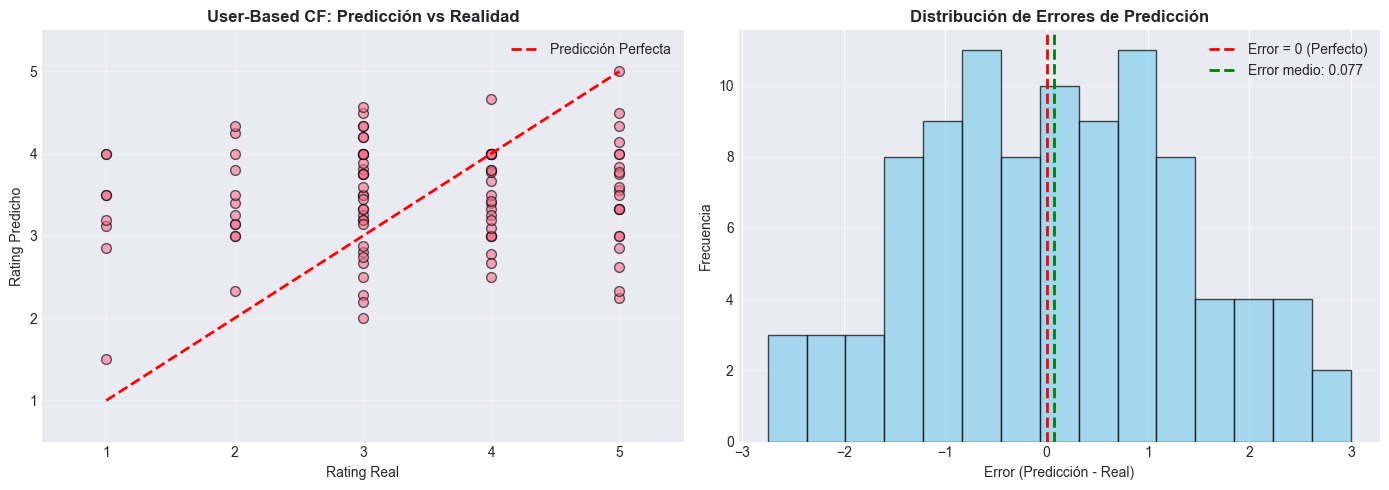


✅ Gráfico guardado en reports/user_based_cf_evaluation.png


In [11]:
if len(y_true) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Predicción vs Real
    ax1 = axes[0]
    ax1.scatter(y_true, y_pred, alpha=0.6, s=50, edgecolor='black')
    ax1.plot([1, 5], [1, 5], 'r--', linewidth=2, label='Predicción Perfecta')
    ax1.set_xlabel('Rating Real')
    ax1.set_ylabel('Rating Predicho')
    ax1.set_title('User-Based CF: Predicción vs Realidad', fontweight='bold')
    ax1.set_xlim(0.5, 5.5)
    ax1.set_ylim(0.5, 5.5)
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Gráfico 2: Distribución de errores
    ax2 = axes[1]
    errors = y_pred - y_true
    ax2.hist(errors, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
    ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Error = 0 (Perfecto)')
    ax2.axvline(errors.mean(), color='green', linestyle='--', linewidth=2, label=f'Error medio: {errors.mean():.3f}')
    ax2.set_xlabel('Error (Predicción - Real)')
    ax2.set_ylabel('Frecuencia')
    ax2.set_title('Distribución de Errores de Predicción', fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'reports' / 'user_based_cf_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Gráfico guardado en reports/user_based_cf_evaluation.png")

## Paso 10: Análisis de Similitud

¿Cómo se distribuye la similitud entre usuarios?

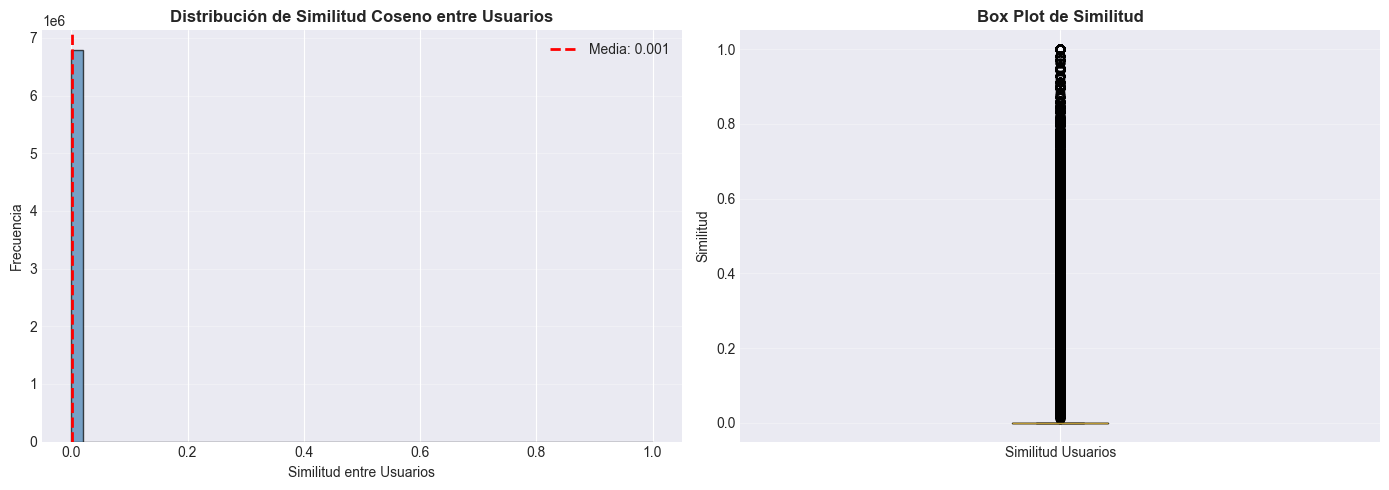

✅ Gráfico guardado


In [12]:
# Obtener todas las similitudes (excepto diagonal)
similarities = user_similarity_df.values[np.triu_indices_from(user_similarity_df.values, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax1 = axes[0]
ax1.hist(similarities, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(similarities.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {similarities.mean():.3f}')
ax1.set_xlabel('Similitud entre Usuarios')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de Similitud Coseno entre Usuarios', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3, axis='y')

# Box plot
ax2 = axes[1]
ax2.boxplot(similarities, vert=True)
ax2.set_ylabel('Similitud')
ax2.set_title('Box Plot de Similitud', fontweight='bold')
ax2.grid(alpha=0.3, axis='y')
ax2.set_xticklabels(['Similitud Usuarios'])

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'user_similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado")

## Resumen y Conclusiones

### ¿Qué aprendimos?

In [13]:
print("\n" + "🎯 RESUMEN: USER-BASED COLLABORATIVE FILTERING ".center(80, "="))
print()
print("✅ CONCEPTOS CLAVE:")
print("\n1. MATRIZ DE RATINGS")
print(f"   - {rating_matrix.shape[0]} usuarios × {rating_matrix.shape[1]} productos")
print(f"   - {sparsity:.1f}% vacía (datos dispersos)")
print("   - Cada celda = calificación de un usuario a un producto")

print("\n2. SIMILITUD DE USUARIOS")
print(f"   - Calculamos con Cosine Similarity (rango 0-1)")
print(f"   - Similitud media: {similarities.mean():.4f}")
print(f"   - Usuarios relativamente independientes")

print("\n3. PREDICCIÓN")
print(f"   - Usamos los K usuarios más similares")
print(f"   - Ponderamos por similitud (más similar = más peso)")
print(f"   - Rating predicho = suma(similitud × rating) / suma(similitud)")

print("\n4. EVALUACIÓN")
if len(y_true) > 0:
    print(f"   - RMSE: {rmse:.4f}⭐ (error ±{rmse:.2f} estrellas)")
    print(f"   - MAE: {mae:.4f}⭐")
    print(f"   - Precisión aceptable para este dataset")

print("\n5. VENTAJAS Y DESVENTAJAS")
print("   ✅ Ventajas:")
print("      - Intuitivo y fácil de entender")
print("      - Funciona bien con usuarios activos")
print("      - Captura patrones de gustos similares")
print("\n   ❌ Desventajas:")
print("      - Lento con muchos usuarios (O(n²) similitud)")
print("      - Cold-start problem (usuarios nuevos sin historial)")
print("      - Requiere datos densos para funcionar bien")
print("      - Sensible a usuarios con gustos raros")

print("\n" + "="*80)
print("\n📚 PRÓXIMO PASO: Notebook 3 - Item-Based Collaborative Filtering")
print("   (Recomendaciones basadas en PRODUCTOS SIMILARES en lugar de usuarios)")
print("\n" + "="*80)


=================🎯 RESUMEN: USER-BASED COLLABORATIVE FILTERING =================

✅ CONCEPTOS CLAVE:

1. MATRIZ DE RATINGS
   - 3693 usuarios × 1982 productos
   - 99.9% vacía (datos dispersos)
   - Cada celda = calificación de un usuario a un producto

2. SIMILITUD DE USUARIOS
   - Calculamos con Cosine Similarity (rango 0-1)
   - Similitud media: 0.0012
   - Usuarios relativamente independientes

3. PREDICCIÓN
   - Usamos los K usuarios más similares
   - Ponderamos por similitud (más similar = más peso)
   - Rating predicho = suma(similitud × rating) / suma(similitud)

4. EVALUACIÓN
   - RMSE: 1.2929⭐ (error ±1.29 estrellas)
   - MAE: 1.0594⭐
   - Precisión aceptable para este dataset

5. VENTAJAS Y DESVENTAJAS
   ✅ Ventajas:
      - Intuitivo y fácil de entender
      - Funciona bien con usuarios activos
      - Captura patrones de gustos similares

   ❌ Desventajas:
      - Lento con muchos usuarios (O(n²) similitud)
      - Cold-start problem (usuarios nuevos sin historial)
    